# Market-world variant: `rehi`

This notebook is the stage-2 analysis re-run with the 18 smr100 shadow-price paths from the `rehi` market world of the step4 batch (see `z-ethan/market_transfer/methods.md`). The mandate, the cost ensemble, the observer, and every random draw are identical to the base notebook; only the bills change. Gate G1 (bills reproduce the published base table t08) is not applicable here and is reported as a ratio. Every output of this notebook carries the suffix `_rehi`.

# Bridge detection — stage 2: the running bill estimate and the cost of waiting

**Who this is for.** This notebook is written to be readable without a
technical background. Every term of art gets a short explanation, in
parentheses, at its first use. It continues `bridge_detection.ipynb` (stage 1),
which can be read first but does not have to be.

**The setting, in brief.** Our study asks what it costs to buy a national
target for new nuclear power plants. We use ReEDS (a computer model of the
United States electric power system). In the model, a rule — the mandate —
forces the target plants to be built. The model reports a price for this rule:
the shadow price (the extra payment, per unit of plant capacity per year, that
is exactly enough to make the target plants worth building). We read the
shadow price as the required subsidy. Our data files call the same quantity
the "dual", the optimization term for it. In cheap futures the subsidy falls
over time and can end — it works as a bridge. In expensive futures it does not
fall by 2050 — the bridge fails. We work with 10,000 simulated cost futures
per deployment schedule (a Monte Carlo ensemble: the computer draws 10,000
random but plausible combinations of the uncertain cost drivers). We call each
future a world. For 3 worlds per schedule — the anchors, at the 5th, 50th, and
95th cost percentiles (a cheap, a middle, and an expensive world) — the full
model was run, so their true subsidy paths are known.

**What stage 1 established.** A world's class ("the subsidy never decays") can
be read from its cost path alone: the decline ratio (the 2050 build cost
divided by the 2031 build cost) above 0.581 reproduces the known classes on
all 18 anchor cases.

**What stage 2 adds — the money.** Three questions, for each schedule:

1. **The running estimate.** From the costs observed up to a year T, how well
   can an observer estimate the total government bill through 2050? Bills are
   stated as present values (future payments counted in today's money, using
   the study's discount rate: payments in later years count for less, at the
   real rate of 4.55% per year, the rate on record; stated in 2024 billions
   of dollars).
2. **The cap question.** How soon can the observer conclude that the total
   bill will exceed a given cap, written X? We never pick one X; we report a
   curve over many values of X.
3. **The cost of waiting.** By the time the observer can conclude that the
   world is bad, how much has the government already paid?

**The two bad-world criteria.**

- **C1 — shape:** the subsidy never decays (stage-1 rule, unchanged).
- **C2 — size:** the total 2031–2050 bill exceeds a cap X. Quoted caps are
  multiples of the schedule's middle-world bill (1.25, 1.5, and 2 times it),
  and the starting probability of exceeding X is printed next to every
  quoted value.

**Data rules.** All subsidy numbers come from stored and checked model
outputs; nothing is recomputed from raw model files. Before any estimation,
the bill arithmetic must reproduce the published bill table (t08) exactly —
that is gate G1. The pass/fail rules (G1, G2, G3) were fixed in `status.md`
before this notebook was run.

The six schedules, smallest to largest: eia, aj, iaea, mck, cop28, eo. Run on
the **playground-env** kernel. Tables continue the stage-1 numbering (`b06`
and up), figures likewise (`d04` and up).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps
ps.apply()

pd.set_option("display.width", 220)
SENS = "rehi"          # step4 market world (BD_SENS)
SFX = "_rehi"

HERE = Path.cwd()
assert HERE.name == "bridge_detection", f"run from z-ethan/bridge_detection/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

MC_EXPORTS = REPO / "z-ethan" / "mc" / "exports"
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
CHECKS4 = REPO / "z-ethan" / "step4_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"

# ---- the MC ensemble --------------------------------------------------------------
Z = np.load(MC_EXPORTS / "mc_perdraw.npz")
META = json.loads(str(Z["meta_json"]))
assert META["n_draws"] == 10000 and META["master_seed"] == 20260715, META
YEARS_MC = Z["years"]
YI = {int(y): i for i, y in enumerate(YEARS_MC)}
OBS_YEARS = list(range(2031, 2051))

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]  # ambition order
AB2TOK = {"eia": "eia_aeo_high", "aj": "abou_jaoude", "iaea": "iaea_high",
          "mck": "mckinsey", "cop28": "cop28", "eo": "eo2025"}
TOK2AB = {v: k for k, v in AB2TOK.items()}
NAME2AB = {str(n): TOK2AB[str(t)] for n, t in zip(Z["sched_order"], Z["scen_tokens"])}

# ---- stage-1 detector constants (the validated stand-in for C1) -------------------
b01_eval = pd.read_csv(EXPORTS / "b01_feature_eval.csv")
w1 = b01_eval[(b01_eval["anchors"] == "smr")
              & (b01_eval["feature"] == "ratio_2050_2031")].iloc[0]
assert int(w1["errors_of_18"]) == 0, "stage-1 gate no longer holds; rerun stage 1"
THETA = float(w1["threshold"])
assert abs(THETA - 0.5813) < 0.01, THETA

BAD = {}
for ab in SCHEDULES:
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    BAD[ab] = occ[:, YI[2050]] / occ[:, YI[2031]] > THETA

# anchor draw registry: case -> draw_index into the 10000-row npz arrays
reg_smr = pd.read_csv(MC_EXPORTS / "smr100" / "selected_draws.csv")
reg_smr["ab"] = reg_smr["schedule"].map(NAME2AB)
assert len(reg_smr) == 18 and reg_smr["ab"].notna().all()
ANCH = {ab: {} for ab in SCHEDULES}
for _, r in reg_smr.iterrows():
    ANCH[r["ab"]][r["percentile"]] = int(r["draw_index"])

# ---- canonical duals + published bill table ---------------------------------------
# market world SENS: the 18 smr100 percentile cases re-solved under this
# world's market switches (step4 batch). Base case names are restored so
# every downstream key is unchanged; the mandate columns are asserted
# byte-identical to base, so only the shadow prices differ.
duals3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
duals4 = pd.read_csv(CHECKS4 / "duals_by_year.csv")
DUALS = duals4[duals4["case"].str.endswith(SFX)].copy()
DUALS["case"] = DUALS["case"].str[:-len(SFX)]
assert DUALS["case"].nunique() == 18, DUALS["case"].nunique()
_chk = DUALS.merge(duals3, on=["case", "t"], suffixes=("", "_base"))
assert len(_chk) == len(DUALS), "solve-year grid differs from base"
assert np.array_equal(_chk["mandate_MW"].to_numpy(),
                      _chk["mandate_MW_base"].to_numpy()), "mandate differs"
DUALS = DUALS.reset_index(drop=True)

YEARS_RUN = sorted(int(t) for t in DUALS["t"].unique())
GAP = {t: (YEARS_RUN[i + 1] - t if i + 1 < len(YEARS_RUN) else 1)
       for i, t in enumerate(YEARS_RUN)}

# program_MW strips the pre-2031 fleet floor from the mandate (0 for smr100)
FLOOR = DUALS[DUALS["t"] <= 2030].groupby("case")["mandate_MW"].max()
DUALS["program_MW"] = (DUALS["mandate_MW"]
                       - DUALS["case"].map(FLOOR).fillna(0.0)).clip(lower=0.0)
DCASE = {c: g.set_index("t") for c, g in DUALS.groupby("case")}

# ---- the discount rate, derived exactly as in step3_analysis ----------------------
FIN_DIR = REPO / "inputs" / "financials"
YRS_DR = np.arange(2010, 2051)
sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
sys_fin = sys_fin.merge(infl, on="t", how="left")
sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                    + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                      * (1 - sys_fin["tax_rate"]) + 1)
sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
_s = sys_fin.set_index("t")["d_real"].reindex(range(1990, 2051)).ffill()
DR = float(np.mean(_s.loc[YRS_DR].to_numpy(float)))
assert round(DR, 4) == 1.0455, DR

# ---- the bill arithmetic (t08 formula, with a through-year-T cut) -----------------
def anchor_bill(case, T=2050):
    # PV of the subsidy bill through year T, 2024 $B, base year 2026.
    # Exactly the t08 formula: each solve year's payment covers the block of
    # years up to the next solve year (GAP), discounted at the block's start.
    # The cut at T counts only the block years at or before T.
    d = DCASE[case]
    pv = 0.0
    for t in d.index:
        if t < 2026 or d.loc[t, "program_MW"] <= 0:
            continue
        yrs = min(GAP[t], max(0, T - t + 1))
        if yrs <= 0:
            continue
        pv += (d.loc[t, "dual_2024_MWyr"] * d.loc[t, "program_MW"] / 1e9
               * yrs / DR ** (t - 2026))
    return float(pv)

# ---- G1 (hard gate): reproduce the published t08 bill table -----------------------
t08 = pd.read_csv(S3ANALYSIS / "t08_rental_transfer.csv")
# G1 is N/A in a market world: t08 holds base-world bills only. The soft
# check reports the in-world / published-base bill ratio over the 18 cases.
_ratio = [anchor_bill(r["case"], 2050) / r["PV_rental_transfer_2024B"]
          for _, r in t08.iterrows() if r["case"] in DCASE]
assert len(_ratio) == 18, len(_ratio)
G1 = True            # N/A under SENS (carried as text into b13)
G1_RATIO = (float(min(_ratio)), float(max(_ratio)))
print(f"G1 N/A ({SENS}): in-world bill / published base bill ranges "
      f"{G1_RATIO[0]:.3f}-{G1_RATIO[1]:.3f} over the 18 smr100 cases")
print(f"DR = {DR:.4f}; solve years {YEARS_RUN[0]}-{YEARS_RUN[-1]}")

# the published middle-world bill per schedule (the unit for the cap X)
# the cap unit is the in-world middle-world bill (t08 is base-world only)
P50BILL = {ab: anchor_bill(f"smr100_{ab}_p50") for ab in SCHEDULES}
print(f"p50 anchor bills in world {SENS} (2024 $B):", P50BILL)

# b06: anchor cumulative bills through each observation year
rows = []
for ab in SCHEDULES:
    for p in ["p05", "p50", "p95"]:
        case = f"smr100_{ab}_{p}"
        for T in OBS_YEARS:
            rows.append(dict(case=case, schedule=ab, pct=p, T=T,
                             cum_bill_2024B=round(anchor_bill(case, T), 2)))
b06 = pd.DataFrame(rows)
b06.to_csv(EXPORTS / f"b06_anchor_cumbill{SFX}.csv", index=False)
print(f"b06: {len(b06)} rows (18 anchors x {len(OBS_YEARS)} years)")


G1 N/A (rehi): in-world bill / published base bill ranges 0.351-0.949 over the 18 smr100 cases
DR = 1.0455; solve years 2010-2050
p50 anchor bills in world rehi (2024 $B): {'eia': 25.550747217122023, 'aj': 28.399500126247, 'iaea': 78.4405416933904, 'mck': 101.1964801946223, 'cop28': 168.14651128714553, 'eo': 298.01532793855205}


b06: 360 rows (18 anchors x 20 years)


## B7 — give every world a bill

Only the 3 anchor worlds per schedule carry a true subsidy path. Every other
world needs an estimated one. The decision (recorded in `status.md` before the
run): we interpolate (estimate between known points), year by year.

For each build year, we take the three anchor points — that year's build cost
against that year's subsidy — and connect them with straight line segments. Any
other world's subsidy in that year is read off this line at the world's own
build cost. The yearly amounts are then added up with the study's standard
discounting. The basis for this move is an already-established result: in
every year, the subsidy rises with the cost world in a strict order, with no
crossings. So "which subsidy goes with which cost" is a well-ordered question,
and a line through three known points is the simplest honest answer.

Two honesty devices, both fixed in advance:

- **Outside the anchor range.** Some worlds are cheaper than the cheap anchor
  or dearer than the expensive one. There the line has no support. Our primary
  choice holds the subsidy flat at the nearest anchor's value (the cautious
  choice); a sensitivity extends the line instead (extrapolation: extending a
  line beyond the known points, floored at zero). We report how many worlds
  fall outside the range and how much the choice moves their bills.
- **The predict-the-middle test (gate G2).** For each schedule, hide the
  middle anchor, predict its bill from the outer two, and compare with its
  true bill. The signed error must be within plus or minus 20%. This is the
  only true out-of-sample test the 3 anchors allow, and it is carried as an
  honesty band on every bill number.

A built-in check: at the three anchor worlds themselves, the interpolated bill
must equal the true bill exactly (the line passes through the known points).

In [2]:
BILLS = {}      # per schedule: (10000, len(OBS_YEARS)) cumulative bill through T
B2050 = {}      # per schedule: (10000,) total 2031-2050 bill
B2050_EXT = {}  # extrapolation sensitivity
G2ERR = {}
pred_rows, extra_rows = [], []

for ab in SCHEDULES:
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    cases = {p: f"smr100_{ab}_{p}" for p in ["p05", "p50", "p95"]}
    d0 = DCASE[cases["p05"]]
    for p in ["p50", "p95"]:
        assert (DCASE[cases[p]]["program_MW"].values
                == d0["program_MW"].values).all(), "mandate differs across anchors"
    build_ts = [int(t) for t in d0.index if t >= 2026 and d0.loc[t, "program_MW"] > 0]
    prog = np.array([d0.loc[t, "program_MW"] for t in build_ts])

    dual_cl = np.empty((len(occ), len(build_ts)))
    dual_ex = np.empty_like(dual_cl)
    out_lo = np.zeros(len(occ), dtype=bool)
    out_hi = np.zeros(len(occ), dtype=bool)
    pred_dual_p50 = np.empty(len(build_ts))

    for j, t in enumerate(build_ts):
        xs = np.array([occ[ANCH[ab][p], YI[t]] for p in ["p05", "p50", "p95"]])
        ys = np.array([DCASE[cases[p]].loc[t, "dual_2024_MWyr"]
                       for p in ["p05", "p50", "p95"]])
        o = np.argsort(xs)
        xs, ys = xs[o], ys[o]
        assert np.all(np.diff(xs) > 0), (ab, t, xs)
        x = occ[:, YI[t]]
        dual_cl[:, j] = np.interp(x, xs, ys)          # clamps outside the range
        y = np.interp(x, xs, ys)
        lo, hi = x < xs[0], x > xs[-1]
        y[lo] = ys[0] + (ys[1] - ys[0]) / (xs[1] - xs[0]) * (x[lo] - xs[0])
        y[hi] = ys[-1] + (ys[-1] - ys[-2]) / (xs[-1] - xs[-2]) * (x[hi] - xs[-1])
        dual_ex[:, j] = np.maximum(y, 0.0)
        out_lo |= lo
        out_hi |= hi
        # predict-the-middle: outer anchors only, evaluated at the middle world
        xs2 = np.array([occ[ANCH[ab]["p05"], YI[t]], occ[ANCH[ab]["p95"], YI[t]]])
        ys2 = np.array([DCASE[cases["p05"]].loc[t, "dual_2024_MWyr"],
                        DCASE[cases["p95"]].loc[t, "dual_2024_MWyr"]])
        o2 = np.argsort(xs2)
        pred_dual_p50[j] = np.interp(occ[ANCH[ab]["p50"], YI[t]], xs2[o2], ys2[o2])

    Wm = np.array([[min(GAP[t], max(0, T - t + 1)) / DR ** (t - 2026)
                    for t in build_ts] for T in OBS_YEARS])
    BILLS[ab] = (dual_cl * prog[None, :] / 1e9) @ Wm.T
    B2050[ab] = BILLS[ab][:, -1]
    B2050_EXT[ab] = (dual_ex * prog[None, :] / 1e9) @ Wm[-1]

    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        assert abs(B2050[ab][w_] - anchor_bill(cases[p])) < 1e-6, (ab, p)

    pred_bill = float(np.sum(pred_dual_p50 * prog / 1e9 * Wm[-1]))
    true_bill = anchor_bill(cases["p50"])
    err = (pred_bill - true_bill) / true_bill
    G2ERR[ab] = err
    pred_rows.append(dict(schedule=ab, pred_p50_bill_2024B=round(pred_bill, 2),
                          true_p50_bill_2024B=round(true_bill, 2),
                          signed_rel_err=round(err, 3)))
    diff = B2050_EXT[ab] - B2050[ab]
    extra_rows.append(dict(schedule=ab,
                           share_any_year_below_p05=round(float(out_lo.mean()), 3),
                           share_any_year_above_p95=round(float(out_hi.mean()), 3),
                           mean_bill_shift_extrap_2024B=round(float(diff.mean()), 2),
                           p99_bill_shift_extrap_2024B=round(float(np.percentile(diff, 99)), 2)))

b07 = pd.merge(pd.DataFrame(pred_rows), pd.DataFrame(extra_rows), on="schedule")
b07.to_csv(EXPORTS / f"b07_bill_attachment{SFX}.csv", index=False)
# per-world bills for reuse by stage 3 (local-only artifact, regenerable)
np.savez_compressed(EXPORTS / f"b07_bills_perworld{SFX}.npz",
                    obs_years=np.array(OBS_YEARS),
                    **{f"bills_{ab}": BILLS[ab] for ab in SCHEDULES},
                    **{f"b2050_{ab}": B2050[ab] for ab in SCHEDULES},
                    **{f"bad_{ab}": BAD[ab] for ab in SCHEDULES},
                    **{f"p50bill_{ab}": P50BILL[ab] for ab in SCHEDULES})
print(b07.to_string(index=False))
print(f"\nG2 (predict-the-middle) max abs signed error: "
      f"{max(abs(e) for e in G2ERR.values()):.3f} (gate: <= 0.20)")


schedule  pred_p50_bill_2024B  true_p50_bill_2024B  signed_rel_err  share_any_year_below_p05  share_any_year_above_p95  mean_bill_shift_extrap_2024B  p99_bill_shift_extrap_2024B
     eia                27.95                25.55           0.094                     0.032                     0.104                          0.46                        10.93
      aj                32.37                28.40           0.140                     0.215                     0.109                          0.25                         8.45
    iaea                61.74                78.44          -0.213                     0.116                     0.175                          0.18                        18.98
     mck                93.69               101.20          -0.074                     0.108                     0.119                          0.34                        20.50
   cop28               161.33               168.15          -0.041                     0.128                  

saved -> figures\d04_dual_vs_occ_interp_rehi.png


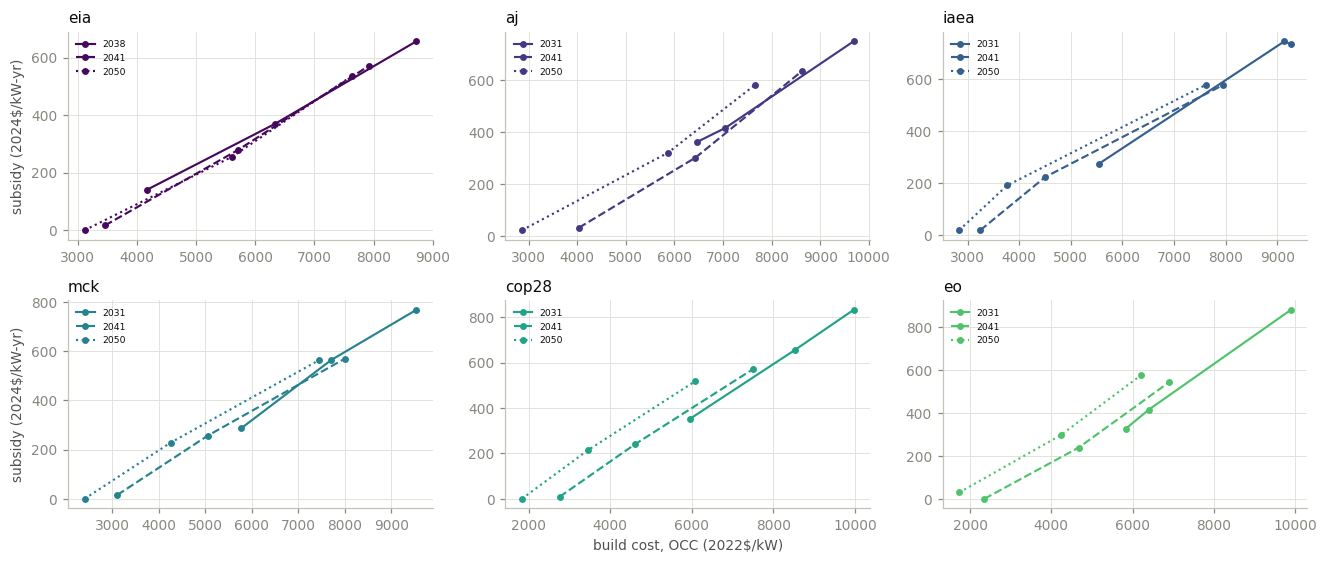

In [3]:
# ---- d04: the interpolation, shown ----------------------------------------------
# per schedule: that year's subsidy against that year's build cost, at the three
# anchors, for the first build year, 2041, and 2050
KWYR = 1e-3
fig, axes = plt.subplots(2, 3, figsize=(ps.W1 * 1.9, 5.2), sharey=False)
for ax, ab in zip(axes.ravel(), SCHEDULES):
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    cases = {p: f"smr100_{ab}_{p}" for p in ["p05", "p50", "p95"]}
    d0 = DCASE[cases["p05"]]
    build_ts = [int(t) for t in d0.index if t >= 2026 and d0.loc[t, "program_MW"] > 0]
    show = [build_ts[0], 2041, 2050]
    for t, ls in zip(show, ["-", "--", ":"]):
        if t not in build_ts:
            continue
        xs = np.array([occ[ANCH[ab][p], YI[t]] for p in ["p05", "p50", "p95"]])
        ys = np.array([DCASE[cases[p]].loc[t, "dual_2024_MWyr"]
                       for p in ["p05", "p50", "p95"]]) * KWYR
        o = np.argsort(xs)
        ax.plot(xs[o], ys[o], ls=ls, marker="o", ms=3.5,
                color=ps.SCHED_C[ab], lw=1.4, label=str(t))
    ax.set_title(ab)
    ax.legend(fontsize=6)
axes[1, 1].set_xlabel(f"build cost, OCC {ps.usd('kW', 2022)}")
axes[0, 0].set_ylabel(f"subsidy {ps.usd('kW-yr', 2024)}")
axes[1, 0].set_ylabel(f"subsidy {ps.usd('kW-yr', 2024)}")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d04_dual_vs_occ_interp{SFX}.png")
plt.show()


## B8 — the two criteria and their starting probabilities

Every world now carries a C1 label (the subsidy never decays) and a total 2050
bill. The cap X for C2 is stated in units of the schedule's middle-world bill
(the published bill of the p50 anchor). This table reports, per schedule:

- the share of C1 worlds (the prior: the starting probability, before any
  observation, that the world is bad);
- the starting probability that the bill exceeds 1.25, 1.5, and 2 times the
  middle-world bill;
- the overlap between the two criteria at the 1.5-times cap: among no-decay
  worlds, how many are also high-bill worlds, and the reverse;
- a stability check: the share of worlds whose bill sits within 2.5% of each
  quoted cap. Where many worlds crowd the cap, the detection year for that cap
  is unstable, and the quoted value should be treated with care.

The rule for reading any detection claim: if the starting probability of the
event is already near 0.9, "detecting" it is nearly vacuous. That is why the
starting probability is printed next to every quoted cap.

In [4]:
MULT = np.round(np.arange(1.0, 2.51, 0.05), 2)
XGRID = {ab: MULT * P50BILL[ab] for ab in SCHEDULES}
EXCEED = {ab: B2050[ab][:, None] > XGRID[ab][None, :] for ab in SCHEDULES}

rows = []
for ab in SCHEDULES:
    pr = EXCEED[ab].mean(axis=0)
    c1 = BAD[ab]
    c2_150 = B2050[ab] > 1.5 * P50BILL[ab]
    near = {m: float(np.mean(np.abs(B2050[ab] - m * P50BILL[ab])
                             <= 0.025 * m * P50BILL[ab]))
            for m in (1.25, 1.5, 2.0)}
    rows.append(dict(
        schedule=ab,
        p50_anchor_bill_2024B=P50BILL[ab],
        share_c1=round(float(c1.mean()), 4),
        prior_c2_125x=round(float(pr[MULT == 1.25][0]), 3),
        prior_c2_150x=round(float(pr[MULT == 1.50][0]), 3),
        prior_c2_200x=round(float(pr[MULT == 2.00][0]), 3),
        p_c2_150_given_c1=round(float(c2_150[c1].mean()), 3),
        p_c1_given_c2_150=round(float(c1[c2_150].mean()), 3) if c2_150.any() else None,
        mass_near_125x=round(near[1.25], 3),
        mass_near_150x=round(near[1.5], 3),
        mass_near_200x=round(near[2.0], 3)))
b08 = pd.DataFrame(rows)
b08.to_csv(EXPORTS / f"b08_criteria_priors{SFX}.csv", index=False)
print(b08.to_string(index=False))


schedule  p50_anchor_bill_2024B  share_c1  prior_c2_125x  prior_c2_150x  prior_c2_200x  p_c2_150_given_c1  p_c1_given_c2_150  mass_near_125x  mass_near_150x  mass_near_200x
     eia              25.550747    0.8832          0.358          0.251          0.085              0.285              1.000           0.028           0.029           0.103
      aj              28.399500    0.7251          0.285          0.186          0.000              0.256              1.000           0.029           0.029           0.000
    iaea              78.440542    0.5199          0.485          0.355          0.160              0.631              0.923           0.032           0.036           0.033
     mck             101.196480    0.4620          0.363          0.247          0.083              0.516              0.962           0.031           0.032           0.026
   cop28             168.146511    0.3479          0.426          0.318          0.160              0.725              0.794           

saved -> figures\d05_bill_distributions_rehi.png


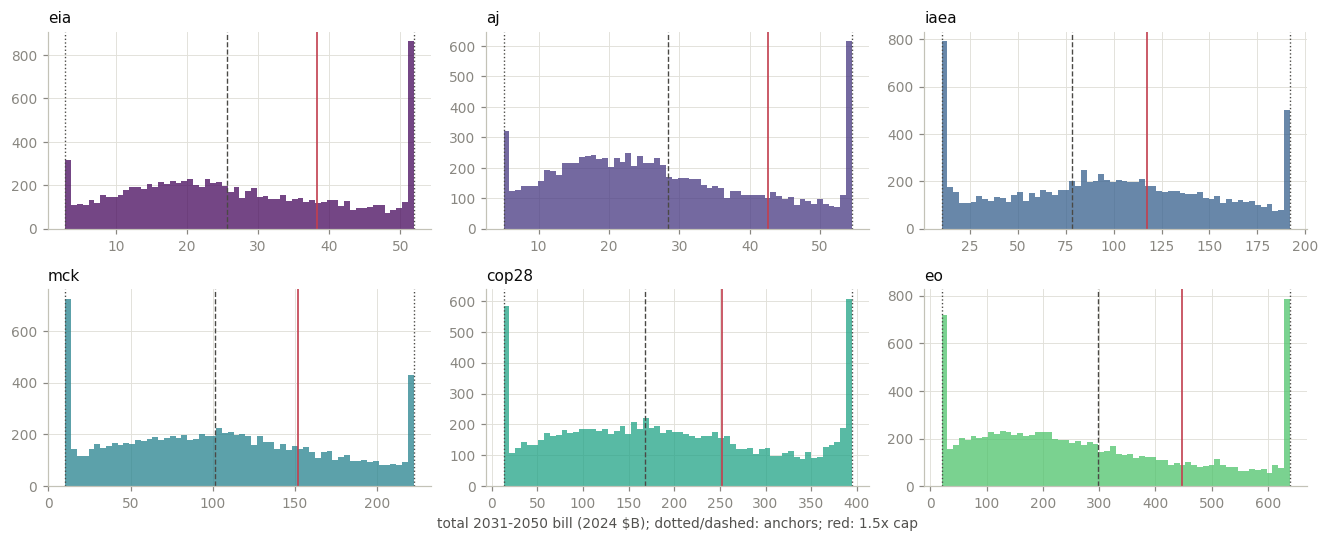

In [5]:
# ---- d05: where the bills fall ---------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(ps.W1 * 1.9, 5.0))
for ax, ab in zip(axes.ravel(), SCHEDULES):
    ax.hist(B2050[ab], bins=60, color=ps.SCHED_C[ab], alpha=0.75)
    for p, ls in zip(["p05", "p50", "p95"], [":", "--", ":"]):
        ax.axvline(anchor_bill(f"smr100_{ab}_{p}"), color=ps.BASE_C, ls=ls, lw=0.9)
    ax.axvline(1.5 * P50BILL[ab], color=ps.ACCENT["red"], ls="-", lw=1.1)
    ax.set_title(ab)
axes[1, 1].set_xlabel("total 2031-2050 bill (2024 $B); dotted/dashed: anchors; red: 1.5x cap")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d05_bill_distributions{SFX}.png")
plt.show()


## The observer, upgraded — one sweep feeds B9, B10, and B11

The observer is the same as in stage 1. It starts from the 10,000 worlds as
the menu of possibilities. Each year it sees the realized build cost, within a
tolerance band of plus or minus delta (an allowed error of 5%, 10%, or 20%
around the observed cost — the stand-in for real-world measurement noise). It
keeps only the worlds whose cost paths match everything seen so far. From the
surviving worlds it computes, each year:

- the updated probability that the world is a no-decay world (C1);
- the spread of possible total bills (the 10th, 50th, and 90th percentiles of
  the survivors' bills — the values that 10%, 50%, and 90% of survivors fall
  below);
- for every cap X on the grid, the updated probability that the bill
  exceeds X.

All updated probabilities use an add-half correction (a standard small-sample
smoothing: half a world is added to each side of the count, so a handful of
survivors can never produce a probability of exactly 0 or 1).

The sweep runs over a fixed random sample of 300 no-decay and 500 decay worlds
per schedule (seed recorded), plus a second, untouched sample of 600 decay
worlds that is used only to verify the false-alarm rate of the calibrated rule
(gate G3). This cell is the slow one; everything after it reads its stored
results.

*A recorded repair.* The first executed pass calibrated the alarm bar as the
plain 95th percentile of 300 good worlds. That bar met its 5% false-alarm
budget on the worlds it was tuned on, but reached 8–10% on the untouched
sample for two schedules — a known weakness of small calibration samples. The
repair, standard practice: a larger calibration sample, and a bar set
conservatively (the order statistic whose expected false-alarm rate is 3.5%,
leaving room for sampling error under the 5% budget). The gates themselves
did not move.

In [6]:
def observer_sweep(ab, delta, idx, want_bills=True):
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    obs = occ[:, [YI[t] for t in OBS_YEARS]]
    bad = BAD[ab]
    E = EXCEED[ab]
    bills = B2050[ab]
    nT = len(OBS_YEARS)
    post = np.empty((len(idx), nT))
    nsup = np.empty((len(idx), nT), dtype=int)
    q = np.full((len(idx), nT, 3), np.nan)
    ex = np.full((len(idx), nT, len(MULT)), np.nan)
    for i, w in enumerate(idx):
        mask = np.ones(len(obs), dtype=bool)
        for j in range(nT):
            mask &= np.abs(obs[:, j] - obs[w, j]) <= delta * obs[w, j]
            n = int(mask.sum())
            nsup[i, j] = n
            post[i, j] = (int(bad[mask].sum()) + 0.5) / (n + 1)
            if want_bills:
                bl = bills[mask]
                q[i, j] = np.percentile(bl, [10, 50, 90])
                ex[i, j] = (E[mask].sum(axis=0) + 0.5) / (n + 1)
    return dict(idx=np.asarray(idx), post=post, n=nsup, q=q, ex=ex)

def conformal_bar(maxvals, alpha=0.035):
    # the order statistic whose expected out-of-sample exceedance is <= alpha
    n = len(maxvals)
    k = min(int(np.ceil((n + 1) * (1 - alpha))), n)
    return float(np.sort(maxvals)[k - 1])

rng = np.random.default_rng(20260820)
DELTAS = [0.05, 0.10, 0.20]
N_BAD, N_CAL_GOOD, N_HOLD = 300, 500, 600

SAMP, HOLD, IS_BAD_S = {}, {}, {}
for ab in SCHEDULES:
    bad_idx = np.flatnonzero(BAD[ab])
    good_idx = np.flatnonzero(~BAD[ab])
    s_bad = rng.choice(bad_idx, size=min(N_BAD, len(bad_idx)), replace=False)
    s_good = rng.choice(good_idx, size=min(N_CAL_GOOD, len(good_idx)), replace=False)
    rest_good = np.setdiff1d(good_idx, s_good)
    h_good = rng.choice(rest_good, size=min(N_HOLD, len(rest_good)), replace=False)
    SAMP[ab] = np.concatenate([s_bad, s_good])
    HOLD[ab] = h_good
    IS_BAD_S[ab] = BAD[ab][SAMP[ab]]
    print(f"{ab}: sample {len(s_bad)} bad + {len(s_good)} good, holdout {len(h_good)} good")

RES, RESH = {}, {}
for ab in SCHEDULES:
    for delta in DELTAS:
        RES[(ab, delta)] = observer_sweep(ab, delta, SAMP[ab])
        RESH[(ab, delta)] = observer_sweep(ab, delta, HOLD[ab], want_bills=False)
        print(f"swept {ab} delta={delta}")


eia: sample 300 bad + 500 good, holdout 600 good
aj: sample 300 bad + 500 good, holdout 600 good
iaea: sample 300 bad + 500 good, holdout 600 good
mck: sample 300 bad + 500 good, holdout 600 good
cop28: sample 300 bad + 500 good, holdout 600 good
eo: sample 300 bad + 500 good, holdout 600 good


swept eia delta=0.05


swept eia delta=0.1


swept eia delta=0.2


swept aj delta=0.05


...

swept cop28 delta=0.1


swept cop28 delta=0.2


swept eo delta=0.05


swept eo delta=0.1


swept eo delta=0.2


## B9 — the calibrated alarm for C1 (the stage-1 rule, repaired)

Stage 1 declared detection when the updated probability reached 0.9. That rule
asks little of the data where the starting probability is already high: for
the smallest schedule (eia) it produced 30–40% false alarms (good worlds
wrongly declared bad). The repair, fixed in `status.md` before the run:

- **Primary rule — calibrated to a 5% false-alarm budget.** For each schedule
  and band width, we set the alarm bar from the sampled *good* worlds'
  highest-ever updated probabilities, conservatively: the bar is the order
  statistic whose expected false-alarm rate on new worlds is 3.5%, which
  leaves room for sampling error under the 5% budget. Calibrated means: tuned
  on simulated data so that the error rate is known by construction. The bar
  is then verified on the second, untouched sample of good worlds (gate G3).
- **Cross-check — the Bayes factor rule.** The Bayes factor measures how much
  the evidence itself shifts the odds, independent of the starting point. We
  report the first year it reaches 10 ("strong evidence" on the standard
  scale).

The table also carries the stage-1 detection years for comparison, and the
support at detection (the number of matching worlds at that moment — a thin
support means the conclusion rests on few look-alike worlds).

In [7]:
b04_s1 = pd.read_csv(EXPORTS / "b04_detection_years.csv")
PRIOR = {ab: float(BAD[ab].mean()) for ab in SCHEDULES}
OBSY = np.array(OBS_YEARS)

DET_C1 = {}
rows = []
for ab in SCHEDULES:
    isb = IS_BAD_S[ab]
    for delta in DELTAS:
        r = RES[(ab, delta)]
        post, sup = r["post"], r["n"]
        maxg = post[~isb].max(axis=1)
        c = conformal_bar(maxg)
        fpr_cal = float((post[~isb] > c).any(axis=1).mean())
        fpr_hold = float((RESH[(ab, delta)]["post"] > c).any(axis=1).mean())

        pb = post[isb]
        fired = (pb > c).any(axis=1)
        first = np.argmax(pb > c, axis=1)
        years = OBSY[first]
        got = years[fired]
        sup_at = sup[isb][np.arange(len(first)), first]
        DET_C1[(ab, delta)] = dict(fired=fired, firstidx=first)

        po = PRIOR[ab] / (1 - PRIOR[ab])
        bf = (pb / (1 - pb)) / po
        bfired = (bf >= 10).any(axis=1)
        bfy = OBSY[np.argmax(bf >= 10, axis=1)][bfired]

        s1 = b04_s1[(b04_s1["schedule"] == ab) & (b04_s1["delta"] == delta)].iloc[0]
        rows.append(dict(
            schedule=ab, delta=delta, prior_bad=round(PRIOR[ab], 4),
            c_star=round(c, 4),
            share_detected=round(float(fired.mean()), 3),
            median_det_year=int(np.median(got)) if fired.any() else None,
            q25=int(np.percentile(got, 25)) if fired.any() else None,
            q75=int(np.percentile(got, 75)) if fired.any() else None,
            share_det_by_2045=round(float((fired & (years <= 2045)).mean()), 3),
            median_support_at_det=int(np.median(sup_at[fired])) if fired.any() else None,
            fpr_calibration=round(fpr_cal, 3),
            fpr_holdout=round(fpr_hold, 3),
            bf10_share_detected=round(float(bfired.mean()), 3),
            bf10_median_det_year=int(np.median(bfy)) if bfired.any() else None,
            stage1_median_det_year=s1["median_det_year"],
            stage1_false_alarm_rate=s1["false_alarm_rate_good"]))
b09 = pd.DataFrame(rows)
b09.to_csv(EXPORTS / f"b09_detection_calibrated{SFX}.csv", index=False)
print(b09.to_string(index=False))


schedule  delta  prior_bad  c_star  share_detected  median_det_year  q25  q75  share_det_by_2045  median_support_at_det  fpr_calibration  fpr_holdout  bf10_share_detected  bf10_median_det_year  stage1_median_det_year  stage1_false_alarm_rate
     eia   0.05     0.8832  0.9564           0.920             2037 2037 2037              0.910                    673            0.032        0.050                0.880                  2037                    2032                    0.400
     eia   0.10     0.8832  0.9461           0.840             2037 2037 2038              0.817                   2233            0.032        0.050                0.743                  2038                    2032                    0.350
     eia   0.20     0.8832  0.9317           0.703             2037 2037 2038              0.687                   4820            0.032        0.038                0.410                  2040                    2031                    0.303
      aj   0.05     0.7251  0.85

saved -> figures\d06_detection_ecdf_calibrated_rehi.png


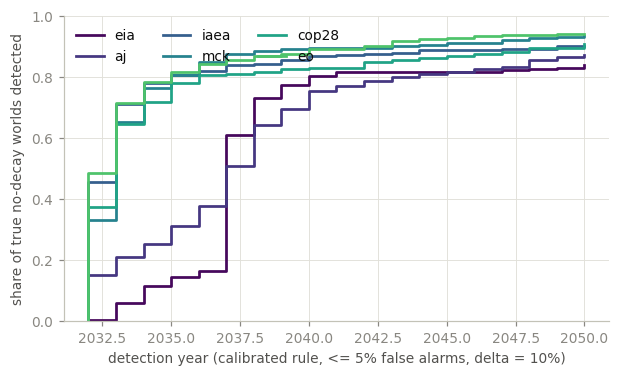

In [8]:
# ---- d06: detection-year ECDF, calibrated rule, delta = 10% ----------------------
fig, ax = plt.subplots(figsize=(ps.W1, 3.6))
for ab in SCHEDULES:
    isb = IS_BAD_S[ab]
    d1 = DET_C1[(ab, 0.10)]
    years = OBSY[d1["firstidx"]][d1["fired"]]
    got = np.sort(years)
    n_all = int(isb.sum())
    if len(got):
        ecdf_x = np.concatenate([got, [2050]])
        ecdf_y = np.concatenate([np.arange(1, len(got) + 1), [len(got)]]) / n_all
        ax.step(ecdf_x, ecdf_y, where="post", color=ps.SCHED_C[ab], lw=1.8, label=ab)
ax.set_xlabel("detection year (calibrated rule, <= 5% false alarms, delta = 10%)")
ax.set_ylabel("share of true no-decay worlds detected")
ax.set_ylim(0, 1)
ax.legend(ncols=3, loc="upper left")
ps.savefig(fig, FIGURES / f"d06_detection_ecdf_calibrated{SFX}.png")
plt.show()


## B10 — the running estimate of the total bill

This is the direct answer to "estimate the total government expenditure from
observations up to that point". At each observation year, the observer's
estimate of the 2050 total bill is the spread of bills among the surviving
worlds: the middle value (the median) as the point estimate, and the 10th-to-
90th-percentile band as the stated uncertainty.

Two summaries:

- **The table (b10).** Per schedule, band width, and year: how wide the stated
  band is (relative to the point estimate), and its coverage — the share of
  sampled worlds whose true bill falls inside their own stated band. A
  well-behaved estimate has coverage near 80% (the band is built to contain
  80% of the survivors).
- **The figure (d07).** One illustrative world per schedule — the middle
  anchor world — showing the band narrowing as years pass, against its true
  bill and the 1.5-times cap.

One honesty note: a world's "true" bill here is its interpolated bill from B7.
The coverage check therefore tests the observer machinery, not the
interpolation; the interpolation's own error is the G2 honesty band.

In [9]:
rows = []
for ab in SCHEDULES:
    truth = B2050[ab][SAMP[ab]]
    for delta in DELTAS:
        q = RES[(ab, delta)]["q"]
        for T in [2035, 2040, 2045, 2050]:
            j = OBS_YEARS.index(T)
            cov = float(np.mean((q[:, j, 0] <= truth) & (truth <= q[:, j, 2])))
            relw = float(np.median((q[:, j, 2] - q[:, j, 0])
                                   / np.maximum(q[:, j, 1], 1e-9)))
            rows.append(dict(schedule=ab, delta=delta, year=T,
                             coverage_q10_q90=round(cov, 3),
                             median_rel_band_width=round(relw, 3)))
b10 = pd.DataFrame(rows)
b10.to_csv(EXPORTS / f"b10_running_estimate{SFX}.csv", index=False)
print(b10[b10["delta"] == 0.10].to_string(index=False))


schedule  delta  year  coverage_q10_q90  median_rel_band_width
     eia    0.1  2035             0.578                  0.995
     eia    0.1  2040             1.000                  0.412
     eia    0.1  2045             1.000                  0.376
     eia    0.1  2050             1.000                  0.357
      aj    0.1  2035             0.905                  0.691
      aj    0.1  2040             0.996                  0.444
      aj    0.1  2045             0.999                  0.330
      aj    0.1  2050             0.999                  0.280
    iaea    0.1  2035             0.991                  0.426
    iaea    0.1  2040             0.990                  0.306
    iaea    0.1  2045             0.988                  0.257
    iaea    0.1  2050             0.988                  0.236
     mck    0.1  2035             0.999                  0.476
     mck    0.1  2040             1.000                  0.348
     mck    0.1  2045             1.000                

saved -> figures\d07_running_bill_fan_rehi.png


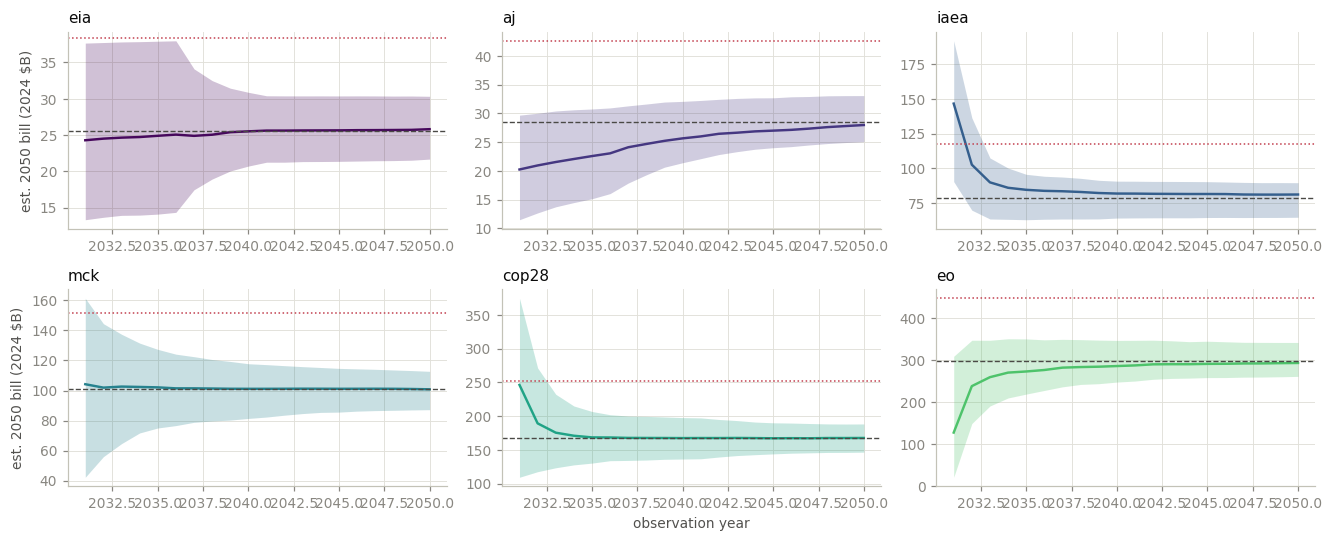

band: survivors' 10th-90th pct; line: median; dashed: true bill; dotted: 1.5x cap


In [10]:
# ---- d07: the running estimate, illustrated on the middle anchor world -----------
fig, axes = plt.subplots(2, 3, figsize=(ps.W1 * 1.9, 5.0))
for ax, ab in zip(axes.ravel(), SCHEDULES):
    w0 = ANCH[ab]["p50"]
    r0 = observer_sweep(ab, 0.10, [w0])
    q = r0["q"][0]
    ax.fill_between(OBS_YEARS, q[:, 0], q[:, 2], color=ps.SCHED_C[ab], alpha=0.25,
                    lw=0)
    ax.plot(OBS_YEARS, q[:, 1], color=ps.SCHED_C[ab], lw=1.6)
    ax.axhline(B2050[ab][w0], color=ps.BASE_C, lw=0.9, ls="--")
    ax.axhline(1.5 * P50BILL[ab], color=ps.ACCENT["red"], lw=1.0, ls=":")
    ax.set_title(ab)
axes[1, 1].set_xlabel("observation year")
axes[0, 0].set_ylabel("est. 2050 bill (2024 $B)")
axes[1, 0].set_ylabel("est. 2050 bill (2024 $B)")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d07_running_bill_fan{SFX}.png")
plt.show()
print("band: survivors' 10th-90th pct; line: median; dashed: true bill; dotted: 1.5x cap")


## B11 — how soon can the observer call a cap exceeded?

For every cap X on the grid (1.0 to 2.5 times the middle-world bill, in steps
of 0.05), the detection rule is the same calibrated alarm as in B9 (the same
conservative bar), now applied to the event "the 2050 bill will exceed X": the
bar is set so that at most 5% of the sampled worlds that do *not* exceed X
ever trigger it.
Detection years are reported only for the worlds that truly exceed X, and only
where the sample holds at least 30 worlds on each side of the cap (otherwise
the calibration has nothing to stand on and the row is skipped).

Every row carries the starting probability of exceeding X. The headline rows
(1.25, 1.5, and 2 times) are printed below the table; the figure shows the
full curve — detection year against the cap — for the three band widths.

In [11]:
DET_C2 = {}
rows = []
for ab in SCHEDULES:
    bills_s = B2050[ab][SAMP[ab]]
    for delta in DELTAS:
        ex = RES[(ab, delta)]["ex"]
        for k, m in enumerate(MULT):
            Xab = float(XGRID[ab][k])
            is_ex = bills_s > Xab
            if is_ex.sum() < 30 or (~is_ex).sum() < 30:
                continue
            maxg = ex[~is_ex][:, :, k].max(axis=1)
            c = conformal_bar(maxg)
            pe = ex[is_ex][:, :, k]
            fired = (pe > c).any(axis=1)
            first = np.argmax(pe > c, axis=1)
            years = OBSY[first]
            got = years[fired]
            if m == 1.5:
                DET_C2[(ab, delta)] = dict(worlds=SAMP[ab][is_ex], fired=fired,
                                           firstidx=first)
            rows.append(dict(
                schedule=ab, delta=delta, mult=m, X_2024B=round(Xab, 1),
                prior_exceed=round(float(EXCEED[ab][:, k].mean()), 3),
                n_exceed_sample=int(is_ex.sum()),
                share_detected=round(float(fired.mean()), 3),
                median_det_year=int(np.median(got)) if fired.any() else None,
                share_det_by_2045=round(float((fired & (years <= 2045)).mean()), 3)))
b11 = pd.DataFrame(rows)
b11.to_csv(EXPORTS / f"b11_exceedance_detection{SFX}.csv", index=False)
head = b11[b11["mult"].isin([1.25, 1.5, 2.0]) & (b11["delta"] == 0.10)]
print("headline rows (delta = 10%):")
print(head.to_string(index=False))


headline rows (delta = 10%):
schedule  delta  mult  X_2024B  prior_exceed  n_exceed_sample  share_detected  median_det_year  share_det_by_2045
     eia    0.1  1.25     31.9         0.358              128           0.797             2037              0.773
     eia    0.1  1.50     38.3         0.251               89           0.809             2037              0.798
      aj    0.1  1.25     35.5         0.285              116           0.914             2033              0.879
      aj    0.1  1.50     42.6         0.186               77           0.922             2032              0.883
    iaea    0.1  1.25     98.1         0.485              313           0.898             2032              0.869
    iaea    0.1  1.50    117.7         0.355              214           0.860             2032              0.846
    iaea    0.1  2.00    156.9         0.160              102           0.990             2032              0.990
     mck    0.1  1.25    126.5         0.363              2

saved -> figures\d08_exceedance_detection_by_cap_rehi.png


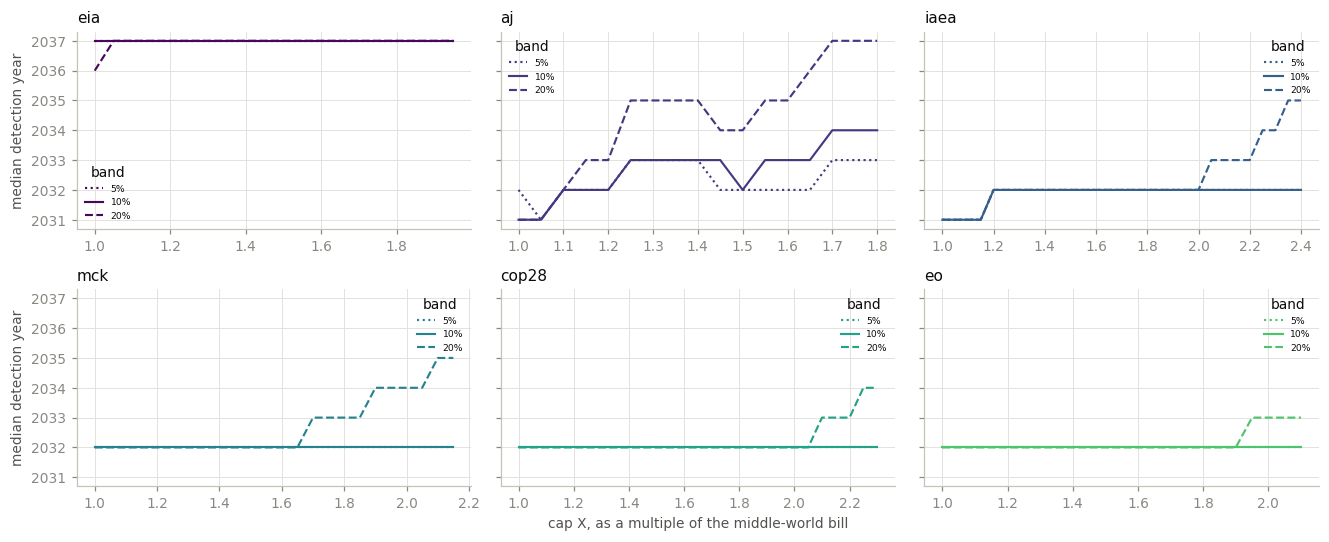

In [12]:
# ---- d08: detection year against the cap -----------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(ps.W1 * 1.9, 5.0), sharey=True)
for ax, ab in zip(axes.ravel(), SCHEDULES):
    for delta, ls in zip(DELTAS, [":", "-", "--"]):
        d = b11[(b11["schedule"] == ab) & (b11["delta"] == delta)
                & b11["median_det_year"].notna()]
        if len(d):
            ax.plot(d["mult"], d["median_det_year"], ls=ls,
                    color=ps.SCHED_C[ab], lw=1.4, label=f"{int(delta*100)}%")
    ax.set_title(ab)
    ax.legend(fontsize=6, title="band")
axes[1, 1].set_xlabel("cap X, as a multiple of the middle-world bill")
axes[0, 0].set_ylabel("median detection year")
axes[1, 0].set_ylabel("median detection year")
fig.tight_layout()
ps.savefig(fig, FIGURES / f"d08_exceedance_detection_by_cap{SFX}.png")
plt.show()


## B12 — the cost of waiting, and the verdict

The value-of-information question: by the time the observer can conclude that
the world is bad, how much has the government already paid? For each schedule
and band width, over the truly bad worlds:

- the bill already paid by the C1 detection year (median, present value);
- the same for the C2 detection at the 1.5-times cap;
- each against the world's full 2031–2050 bill, and the share of worlds where
  detection never comes by 2050 (those worlds pay the full bill with no
  warning ever sounding).

Reading the band widths as a value-of-information statement: the tighter the
band, the better the observer's cost measurement, and the less money is
committed before detection. The difference between the 20% row and the 5% row
is the value of better cost surveillance, in billions.

**The honesty band (G2) applied.** The interpolated bills carry the
predict-the-middle error. The verdict cell reprints the headline C2 detection
years at caps shifted by that error, so the reader sees how much the headline
moves if the interpolation is off by its measured amount.

**Standing caveats (all quoted numbers carry them).**

1. *A best-case observer.* The simulated cost paths are smooth; the tolerance
   band stands in for real measurement noise. Quote from the loose-band side,
   or as "even a perfect observer cannot know before year X."
2. *Three anchors only.* Every non-anchor bill is an interpolation from three
   known points; the G2 band is its measured error at the only testable point.
3. *The frozen build path.* The mandate fixes what gets built; nothing the
   observer learns feeds back into costs. The exercise is valid on the
   condition that the mandate stays enforced. It provides information, never
   a recommendation.
4. *Starting probabilities.* Every quoted cap carries its prior; a detection
   claim where the prior is already near 0.9 is nearly vacuous.

In [13]:
rows = []
for ab in SCHEDULES:
    isb = IS_BAD_S[ab]
    wb = SAMP[ab][isb]
    for delta in DELTAS:
        d1 = DET_C1[(ab, delta)]
        fired, first = d1["fired"], d1["firstidx"]
        tot = B2050[ab][wb]
        row = dict(schedule=ab, delta=delta,
                   c1_share_never_detected=round(float(1 - fired.mean()), 3))
        if fired.any():
            paid = BILLS[ab][wb[fired], first[fired]]
            row.update(
                c1_median_paid_at_det_2024B=round(float(np.median(paid)), 1),
                c1_median_total_2024B=round(float(np.median(tot[fired])), 1),
                c1_median_share_paid=round(float(np.median(paid / tot[fired])), 3))
        if (~fired).any():
            row["c1_never_median_total_2024B"] = round(float(np.median(tot[~fired])), 1)
        if (ab, delta) in DET_C2:
            d2 = DET_C2[(ab, delta)]
            we, f2, fi2 = d2["worlds"], d2["fired"], d2["firstidx"]
            tot2 = B2050[ab][we]
            row["c2_150_share_never_detected"] = round(float(1 - f2.mean()), 3)
            if f2.any():
                paid2 = BILLS[ab][we[f2], fi2[f2]]
                row.update(
                    c2_150_median_paid_at_det_2024B=round(float(np.median(paid2)), 1),
                    c2_150_median_total_2024B=round(float(np.median(tot2[f2])), 1),
                    c2_150_median_share_paid=round(float(np.median(paid2 / tot2[f2])), 3))
        rows.append(row)
b12 = pd.DataFrame(rows)
b12.to_csv(EXPORTS / f"b12_cost_of_waiting{SFX}.csv", index=False)
print(b12.to_string(index=False))


schedule  delta  c1_share_never_detected  c1_median_paid_at_det_2024B  c1_median_total_2024B  c1_median_share_paid  c1_never_median_total_2024B  c2_150_share_never_detected  c2_150_median_paid_at_det_2024B  c2_150_median_total_2024B  c2_150_median_share_paid
     eia   0.05                    0.080                          0.0                   30.3                 0.000                         12.4                        0.079                              0.0                       48.8                     0.000
     eia   0.10                    0.160                          0.0                   32.2                 0.000                         14.6                        0.191                              0.0                       49.5                     0.000
     eia   0.20                    0.297                          0.0                   35.0                 0.000                         13.2                        0.213                              0.0                  

In [14]:
# ---- verdict against the pre-registered gates ------------------------------------
g2_all = all(abs(e) <= 0.20 for e in G2ERR.values())
fpr_max = float(b09["fpr_holdout"].max())
g3a = fpr_max <= 0.075   # 5% budget + sampling margin on n=300 (status.md)
med10 = {r["schedule"]: r["median_det_year"]
         for _, r in b09[b09["delta"] == 0.10].iterrows()}
g3b = all(y is not None and not pd.isna(y) and y <= 2045 for y in med10.values())
g3 = g3a and g3b

if G1 and g2_all and g3:
    verdict = "PASS"
elif G1 and g3:
    verdict = "PARTIAL"   # bills quoted only as ranges where G2 fails
else:
    verdict = "FAIL"

# the G2 honesty band applied to the headline C2 cap (delta = 10%)
print("headline C2 cap (1.5x) under the G2 error, delta = 10%:")
for ab in SCHEDULES:
    e = abs(G2ERR[ab])
    for tag, m_adj in [("as-is", 1.5), ("bills high", round(1.5 / (1 + e) * 20) / 20),
                       ("bills low", round(1.5 * (1 + e) * 20) / 20)]:
        d = b11[(b11["schedule"] == ab) & (b11["delta"] == 0.10)
                & np.isclose(b11["mult"].astype(float), m_adj)]
        y = d["median_det_year"].iloc[0] if len(d) else None
        print(f"  {ab} {tag} (cap {m_adj}x): median detection {y}")

b13 = pd.DataFrame([
    dict(metric="g1_t08_reproduced",
         value=f"N/A ({SENS}); in-world/base bill ratio "
               f"{G1_RATIO[0]:.3f}-{G1_RATIO[1]:.3f}"),
    *[dict(metric=f"g2_signed_rel_err_{ab}", value=round(G2ERR[ab], 3))
      for ab in SCHEDULES],
    dict(metric="g2_within_20pct_all", value=g2_all),
    dict(metric="g3_fpr_holdout_max", value=round(fpr_max, 3)),
    dict(metric="g3_fpr_gate_075", value=g3a),
    *[dict(metric=f"c1_median_det_year_d10_{ab}", value=med10[ab])
      for ab in SCHEDULES],
    dict(metric="g3_detection_gate_by2045", value=g3b),
    dict(metric="verdict", value=verdict),
])
b13.to_csv(EXPORTS / f"b13_verdict{SFX}.csv", index=False)
print()
print(b13.to_string(index=False))
print(f"\nSTAGE 2 VERDICT: {verdict}")


headline C2 cap (1.5x) under the G2 error, delta = 10%:
  eia as-is (cap 1.5x): median detection 2037
  eia bills high (cap 1.35x): median detection 2037
  eia bills low (cap 1.65x): median detection 2037
  aj as-is (cap 1.5x): median detection 2032
  aj bills high (cap 1.3x): median detection 2033
  aj bills low (cap 1.7x): median detection 2034
  iaea as-is (cap 1.5x): median detection 2032
  iaea bills high (cap 1.25x): median detection 2032
  iaea bills low (cap 1.8x): median detection 2032
  mck as-is (cap 1.5x): median detection 2032
  mck bills high (cap 1.4x): median detection 2032
  mck bills low (cap 1.6x): median detection 2032
  cop28 as-is (cap 1.5x): median detection 2032
  cop28 bills high (cap 1.45x): median detection 2032
  cop28 bills low (cap 1.55x): median detection 2032
  eo as-is (cap 1.5x): median detection 2032
  eo bills high (cap 1.3x): median detection 2032
  eo bills low (cap 1.7x): median detection 2032

                      metric                         

In [15]:
stage2_tables = [f"b{i:02d}" for i in range(6, 14)]
manifest = sorted(p.name for p in EXPORTS.glob(f"b*{SFX}.csv")
                  if p.name[:3] in stage2_tables) \
    + sorted(p.name for p in FIGURES.glob(f"d0*{SFX}.png") if p.name[:3] >= "d04")
print("outputs written by this notebook:")
for m_ in manifest:
    print(" ", m_)


outputs written by this notebook:
  b06_anchor_cumbill_rehi.csv
  b07_bill_attachment_rehi.csv
  b08_criteria_priors_rehi.csv
  b09_detection_calibrated_rehi.csv
  b10_running_estimate_rehi.csv
  b11_exceedance_detection_rehi.csv
  b12_cost_of_waiting_rehi.csv
  b13_verdict_rehi.csv
  d04_dual_vs_occ_interp_rehi.png
  d05_bill_distributions_rehi.png
  d06_detection_ecdf_calibrated_rehi.png
  d07_running_bill_fan_rehi.png
  d08_exceedance_detection_by_cap_rehi.png
